   Rank Action Items - No AI in Secret - Provide clarity and transparency  \
0                                                  3                        
1                                                  3                        
2                                                  2                        
3                                                  1                        
4                                                  2                        

   Rank Action Items - No AI in Secret - Be fully transparent when using algorithms  \
0                                                  1                                  
1                                                  2                                  
2                                                  1                                  
3                                                  3                                  
4                                                  3                                  

   Rank Action

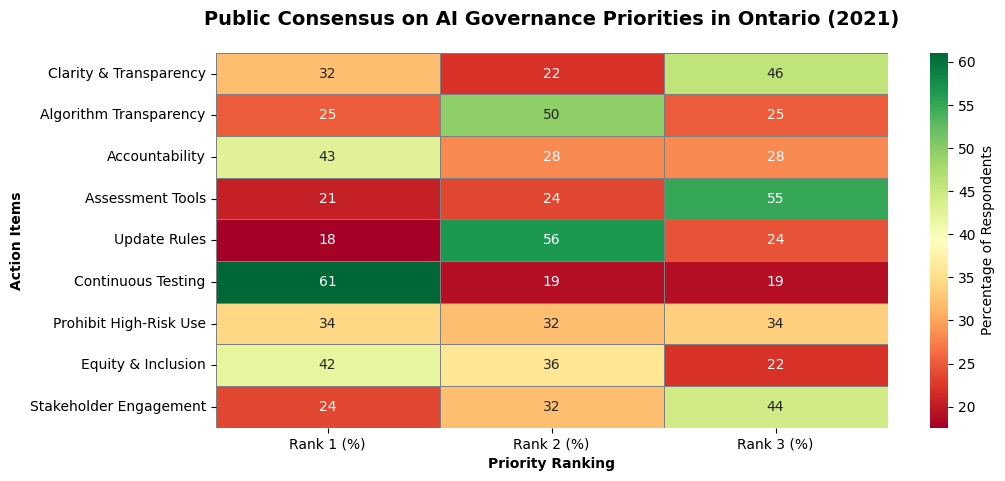


=== FULL RANKING DISTRIBUTION ===
           Action Item  Rank 1 (%)  Rank 2 (%)  Rank 3 (%)
Clarity & Transparency   32.061069   22.137405   45.801527
Algorithm Transparency   25.190840   49.618321   25.190840
        Accountability   42.748092   28.244275   28.244275
      Assessment Tools   20.610687   23.664122   54.961832
          Update Rules   17.557252   56.488550   24.427481
    Continuous Testing   61.068702   19.083969   19.083969
Prohibit High-Risk Use   34.351145   32.061069   33.587786
    Equity & Inclusion   41.984733   35.877863   22.137405
Stakeholder Engagement   23.664122   32.061069   44.274809


In [12]:
### Appendix-1: Python Code for Generating my Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = '/Users/tanveerrouf/Documents/Soc Phd/SOC Fall 2025/Data Science Certificate/visualization/02_activities/assignments/survey_developing_ontarios_artificial_intelligence_abbrai_abbr_framework-sept_19-2022.xlsx'
df = pd.read_excel(file_path)

# Display structure of the data
print(df.head())
print(df.columns)
print(df.shape)

# Extract only ranking columns (integer/float values representing ranks 1, 2, 3)
ranking_columns = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
df_rankings = df[ranking_columns]

# Print exact column names to verify mapping
print("\n=== EXACT COLUMN NAMES ===")
for col in df_rankings.columns:
    print(repr(col))

# Shorten action item names for better readability
action_names = {
    'Rank Action Items - No AI in Secret - Provide clarity and transparency': 'Clarity & Transparency',
    'Rank Action Items - No AI in Secret - Be fully transparent when using algorithms': 'Algorithm Transparency',
    'Rank Action Items - No AI in Secret - Create accountability for the use of AI': 'Accountability',
    'Rank Action Items - AI Use Ontarians Can Trust - Assess whether to use an algorithmic assessment tool': 'Assessment Tools',
    'Rank Action Items - AI Use Ontarians Can Trust - Deliver recommendations on ways to update Ontario’s rules': 'Update Rules',
    'Rank Action Items - AI Use Ontarians Can Trust - Ensuring processes are in place so that algorithms are continuously tested and evaluated ': 'Continuous Testing',
    'Rank Action Items - AI That Serves All Ontarians - Assess whether the government should prohibit the use of AI in certain cases': 'Prohibit High-Risk Use',
    'Rank Action Items - AI That Serves All Ontarians - Embed equity and inclusion': 'Equity & Inclusion',
    'Rank Action Items - AI That Serves All Ontarians - Engage with sector leaders and civil society': 'Stakeholder Engagement'
}

# Calculate percentage distribution of ranking votes (1, 2, 3) per action item
ranking_dist = pd.DataFrame({
    'Action Item': [action_names.get(col, col) for col in df_rankings.columns],
    'Rank 1 (%)': [(df_rankings[col] == 1).sum() / len(df_rankings) * 100 for col in df_rankings.columns],
    'Rank 2 (%)': [(df_rankings[col] == 2).sum() / len(df_rankings) * 100 for col in df_rankings.columns],
    'Rank 3 (%)': [(df_rankings[col] == 3).sum() / len(df_rankings) * 100 for col in df_rankings.columns]
})

# Display top 3 priorities (action items with highest Rank 1 percentage)
print("\n=== TOP 3 PRIORITIES (Highest Rank 1 %) ===")
top_priorities = ranking_dist.nlargest(3, 'Rank 1 (%)')
print(top_priorities[['Action Item', 'Rank 1 (%)']].to_string(index=False))

# Create heatmap visualization
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    ranking_dist.set_index('Action Item')[['Rank 1 (%)', 'Rank 2 (%)', 'Rank 3 (%)']],
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Percentage of Respondents'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray'
)

# Customize plot appearance
ax.set_title('Public Consensus on AI Governance Priorities in Ontario (2021)', fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Priority Ranking', fontweight='bold')
ax.set_ylabel('Action Items', fontweight='bold')

# Adjust layout to prevent label cutoff
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.15)

# Save and display
plt.savefig('viz2_consensus_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== FULL RANKING DISTRIBUTION ===")
print(ranking_dist.to_string(index=False))



In [ ]:
### Appendix-2: Python Code to Automate my Second Excel Visualization
import pandas as pd
from openpyxl import Workbook
from openpyxl.chart import BarChart, Reference
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.chart.axis import ChartLines

# Read original survey dataset
file_path = 'survey_developing_ontarios_artificial_intelligence_abbrai_abbr_framework-sept_19-2022.xlsx'
df_survey = pd.read_excel(file_path)

# Map display names to actual column names
action_items = {
    'Clarity & Transparency': 'Rank Action Items - No AI in Secret - Provide clarity and transparency',
    'Algorithm Transparency': 'Rank Action Items - No AI in Secret - Be fully transparent when using algorithms',
    'Accountability': 'Rank Action Items - No AI in Secret - Create accountability for the use of AI',
    'Assessment Tools': 'Rank Action Items - AI Use Ontarians Can Trust - Assess whether to use an algorithmic assessment tool',
    'Continuous Testing': 'Rank Action Items - AI Use Ontarians Can Trust - Ensuring processes are in place so that algorithms are continuously tested and evaluated ',
    'Prohibit High-Risk Use': 'Rank Action Items - AI That Serves All Ontarians - Assess whether the government should prohibit the use of AI in certain cases',
    'Equity & Inclusion': 'Rank Action Items - AI That Serves All Ontarians - Embed equity and inclusion',
    'Stakeholder Engagement': 'Rank Action Items - AI That Serves All Ontarians - Engage with sector leaders and civil society'
}

# Calculate percentages
results = []
for display_name, column_name in action_items.items():
    if column_name in df_survey.columns:
        rank1_count = (df_survey[column_name] == 1).sum()
        rank2_count = (df_survey[column_name] == 2).sum()
        rank3_count = (df_survey[column_name] == 3).sum()
        total = rank1_count + rank2_count + rank3_count
        rank1_pct = round((rank1_count / total) * 100) if total > 0 else 0
        rank2_pct = round((rank2_count / total) * 100) if total > 0 else 0
        rank3_pct = round((rank3_count / total) * 100) if total > 0 else 0
        results.append({
            'Action Item': display_name,
            'Rank 1': rank1_pct,
            'Rank 2': rank2_pct,
            'Rank 3': rank3_pct
        })

df_rankings = pd.DataFrame(results)

# Create Excel workbook
wb = Workbook()
ws = wb.active
ws.title = 'AI Governance Survey'

# Write headers
headers = ['Action Item', 'Rank 1', 'Rank 2', 'Rank 3']
for c_idx, header in enumerate(headers, 1):
    cell = ws.cell(row=1, column=c_idx, value=header)
    cell.font = Font(bold=True, size=11, color='FFFFFF')
    cell.fill = PatternFill(start_color='1F4E78', end_color='1F4E78', fill_type='solid')
    cell.alignment = Alignment(horizontal='center', vertical='center')

# Write data rows
for r_idx, row in enumerate(df_rankings.values, 2):
    for c_idx, value in enumerate(row, 1):
        cell = ws.cell(row=r_idx, column=c_idx, value=value)
        cell.alignment = Alignment(horizontal='center', vertical='center')
        cell.font = Font(size=10)

# Set column widths
ws.column_dimensions['A'].width = 26
ws.column_dimensions['B'].width = 10
ws.column_dimensions['C'].width = 10
ws.column_dimensions['D'].width = 10

# Create stacked bar chart
chart = BarChart()
chart.type = "col"
chart.grouping = "stacked"
chart.overlap = 100
chart.title = "Public Consensus on AI Governance Priorities in Ontario (2021)"
chart.title.tx.rich.paragraphs[0].rPr = Font(sz=13, b=True)
chart.style = 12
chart.height = 14
chart.width = 22

# Add data to chart
data_ref = Reference(ws, min_col=2, min_row=1, max_row=len(df_rankings) + 1, max_col=4)
categories = Reference(ws, min_col=1, min_row=2, max_row=len(df_rankings) + 1)

chart.add_data(data_ref, titles_from_data=True)
chart.set_categories(categories)

# Assign colors (Green for Rank 1, Yellow for Rank 2, Red for Rank 3)
series_colors = ['70AD47', 'FFC000', 'C5504B']
for idx, series in enumerate(chart.series):
    series.graphicalProperties.solidFill = series_colors[idx]
    series.dLbls = None

# Format axes
chart.x_axis.tickLblPos = "low"
chart.x_axis.label_angle = 45
chart.x_axis.title = "Action Items"
chart.x_axis.title.tx.rich.paragraphs[0].rPr = Font(sz=11, b=True)

chart.y_axis.title = "Percentage of Respondents (%)"
chart.y_axis.scaling.minVal = 0
chart.y_axis.scaling.maxVal = 100
chart.y_axis.majorUnit = 25

# Remove minor gridlines, keep only major gridlines at 25% increments
chart.y_axis.majorGridlines = ChartLines()
chart.y_axis.minorGridlines = None

# Add legend on the right
chart.legend.position = "r"
chart.legend.overlay = False

# Add chart to worksheet
ws.add_chart(chart, "A12")

# Save workbook
output_file = 'AI_Governance_Survey_Visualization.xlsx'
wb.save(output_file)

print(f"Visualization created successfully: {output_file}")
print("\nData:")
print(df_rankings)


Visualization created successfully: AI_Governance_Survey_Visualization.xlsx

Data:
              Action Item  Rank 1  Rank 2  Rank 3
0  Clarity & Transparency      32      22      46
1  Algorithm Transparency      25      50      25
2          Accountability      43      28      28
3        Assessment Tools      21      24      55
4      Continuous Testing      62      19      19
5  Prohibit High-Risk Use      34      32      34
6      Equity & Inclusion      42      36      22
7  Stakeholder Engagement      24      32      44


In [ ]:
## Generating the Excel Visualization Image:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Bringing My data from the Excel Automation Code's Output:
data = {
    'Action Item': ['Clarity & Transparency', 'Algorithm Transparency', 'Accountability', 'Assessment Tools', 'Continuous Testing', 'Prohibit High-Risk Use', 'Equity & Inclusion', 'Stakeholder Engagement'],
    'Rank 1': [32, 25, 43, 21, 62, 34, 42, 24],
    'Rank 2': [22, 50, 28, 24, 19, 32, 36, 32],
    'Rank 3': [46, 25, 28, 55, 19, 34, 22, 44]
}

df = pd.DataFrame(data)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df['Action Item']))
width = 0.6

# Colors: Green, Yellow, Red
colors = ['#70AD47', '#FFC000', '#C5504B']

# Plot stacked bars
ax.bar(x, df['Rank 1'], width, label='Rank 1', color=colors[0])
ax.bar(x, df['Rank 2'], width, bottom=df['Rank 1'], label='Rank 2', color=colors[1])
ax.bar(x, df['Rank 3'], width, bottom=df['Rank 1']+df['Rank 2'], label='Rank 3', color=colors[2])

# Labels and formatting
ax.set_xlabel('Action Items', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Respondents (%)', fontsize=12, fontweight='bold')
ax.set_title('Public Consensus on AI Governance Priorities in Ontario (2021)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Action Item'], rotation=45, ha='right')
ax.set_ylim(0, 100)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save as image
plt.savefig('AI_Governance_Survey_Visualization.png', dpi=300, bbox_inches='tight')
print("Chart saved as AI_Governance_Survey_Visualization.png")
plt.close()


Chart saved as AI_Governance_Survey_Visualization.png
